# Applied Machine Learning
## Homework 1

Harsh Agrawal HA455  
Daniel Xing YX753

Date: 25 September 2026

### Part 1

##### 1. Join the House Prices - Advanced Regression Techniques competition on Kaggle. Download the training and test data.

##### 2. Give 3 examples of continuous and categorical features in the dataset; choose one feature of each type and plot the histogram to illustrate the distribution.



##### Continuous examples:

1) MasVnrArea — masonry veneer area

2) 3SsnPorch — three-season porch area

3) ScreenPorch — screen porch area


##### Categorical examples:

1) GarageType — attached, detached, built-in, etc.

2) RoofStyle — Gable, Hip, Mansard, etc.

3) Foundation — Brick, Stone, Poured Concrete, etc.


##### Pair for the plot:

Continuous: MasVnrArea

Categorical: GarageType

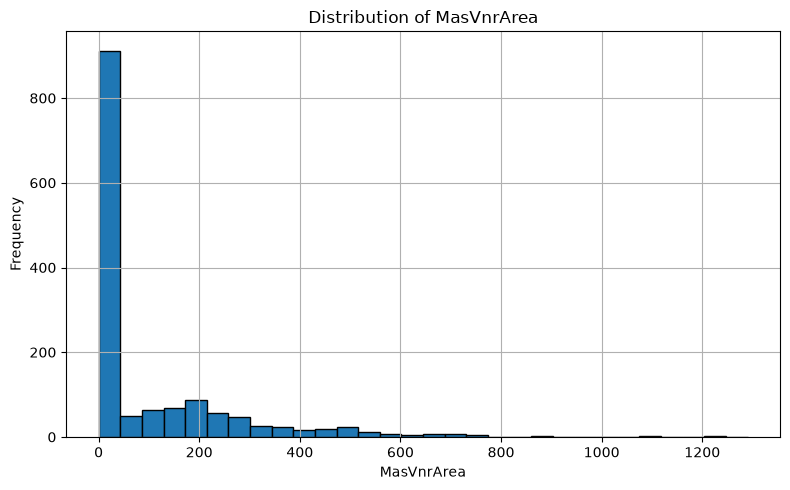

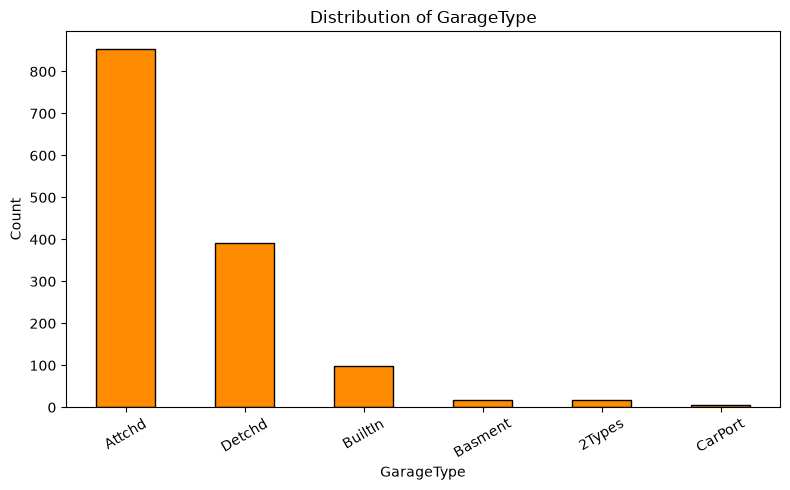

In [7]:


import pandas as pd
import matplotlib.pyplot as plt

train_data = pd.read_csv(r"house-prices-advanced-regression-techniques\test_data.csv")
test_data = pd.read_csv(r"C:\Users\Asus\Desktop\AML Assighnment\test_data.csv")


cont_feature = "MasVnrArea"
plt.figure(figsize=(8, 5))
train_data[cont_feature].hist(bins=30, edgecolor="black")
plt.title(f"Distribution of {cont_feature}")
plt.xlabel(cont_feature)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


cat_feature = "GarageType"
plt.figure(figsize=(8, 5))
train_data[cat_feature].value_counts().plot(kind="bar", color="darkorange", edgecolor="black")
plt.title(f"Distribution of {cat_feature}")
plt.xlabel(cat_feature)
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### Q3. Pre-process your data, explain your pre-processing steps, and the reasons why you need them. (Hint: data pre-processing steps can include but are not restricted to: dealing with missing values, normalizing numerical values, dealing with categorical values etc.) 

Here are the list of my preprocessing steps  : 

1) Before modeling, I separated the target variable SalePrice from the feature set, because the target should not be treated as an input feature.

2) I also removed irrelevant identifiers such as Id, since they do not contain useful predictive information about the house price.

3) The target variable was log-transformed using log1p(SalePrice). This was necessary because house prices are highly right-skewed, and a log transformation reduces the influence of extreme values and makes the target distribution more suitable for regression.

4) I then identified numerical and categorical columns separately, because different preprocessing methods are required for each type.

5) For numerical features, I created missing-value indicator variables. For example, if a value like LotFrontage or GarageYrBlt was missing, I recorded this as a binary flag. This is useful because missingness itself can be informative and often indicates that a feature is not applicable.

6) I handled missing numerical values using median imputation. Median was chosen instead of mean because housing data often contains outliers, and the median is more robust to extreme values.

7) For categorical variables, I handled missing values using the most frequent category. This is appropriate because many categorical features are missing simply because the attribute is absent or unreported, and replacing missing values with the most common category preserves the overall data distribution.

8) I standardized numerical features using StandardScaler. This was important because regression models and many machine learning algorithms perform better when features are on a comparable scale, especially when values differ significantly in magnitude.

9) For categorical variables, I used one-hot encoding. Features such as Neighborhood, GarageType, and MSZoning were converted into binary dummy variables so that each category was represented independently. This is necessary because machines cannot directly learn from categorical labels like “CollgCr” or “Attchd” in their raw form.

10) I also used a ColumnTransformer to apply the different preprocessing steps to the right columns simultaneously. This ensured that numerical features were scaled and imputed correctly, while categorical features were imputed and one-hot encoded in the same pipeline.

11) Finally, I split the preprocessed dataset into training and validation sets so that the model could be evaluated on unseen data and the preprocessing steps could be applied consistently to both subsets.


In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Load the actual data

train_data = pd.read_csv(r"house-prices-advanced-regression-techniques\train.csv")
test_data = pd.read_csv(r"house-prices-advanced-regression-techniques\test.csv")

# 1) Separate target variable from feature set
target = "SalePrice"
X = train_data.drop(columns=[target, "Id"], errors="ignore")
y = train_data[target]

# 2) Log-transform the target
# This reduces right-skewness in house prices
y = np.log1p(y)

# 3) Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

# 4) Create missing-value indicator columns for numeric features
# This captures the fact that missingness itself can be informative
for col in numeric_cols:
    X[f"{col}_Missing"] = X[col].isna().astype(int)
    if col in test_data.columns:
        test_data[f"{col}_Missing"] = test_data[col].isna().astype(int)

# Update numeric columns after adding missing-indicator features
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

# 5) Numeric preprocessing: median imputation + scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 6) Categorical preprocessing: most-frequent imputation + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 7) Combine preprocessing steps for different column types
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# 8) Apply preprocessing to the data
X_processed = preprocessor.fit_transform(X)

# 9) Split into train/validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

print("Training data shape after preprocessing:", X_train.shape)
print("Validation data shape after preprocessing:", X_valid.shape)

Training data shape after preprocessing: (1168, 323)
Validation data shape after preprocessing: (292, 323)


C:\Users\Asus\AppData\Local\Temp\ipykernel_7884\3536441047.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()



##### Q4. One common method of pre-processing categorical features is to use a one-hot encoding (OHE). Suppose that we start with a categorical feature xj , taking three possible values: xj ∈ {R,G,B}. A one-hot encoding of this feature replaces xj with three new features: xjR,xjG,xjB . Each feature contains a binary value of 0 or 1, depending on the value taken by xj . For example, if xj =G, then xjG = 1 and xjR = xjB = 0. Give some examples of features that you think should use a one-hot encoding and explain why. Convert at least one feature to a one-hot encoding (you can use your own implementation, or that in pandas or scikit-learn) and visualize the results by plotting feature histograms of the original feature and its new one-hot encoding.

Examples in the House Prices dataset:

1) GarageType — Attached, Detached, BuiltIn, etc.
2) Neighborhood — different areas like CollgCr, Veenker, OldTown, etc.
3) RoofStyle — Gable, Hip, Mansard, etc.
4) MSZoning — RL, RM, RH, etc.
5) Foundation — Poured Concrete, Brick, Stone, etc.

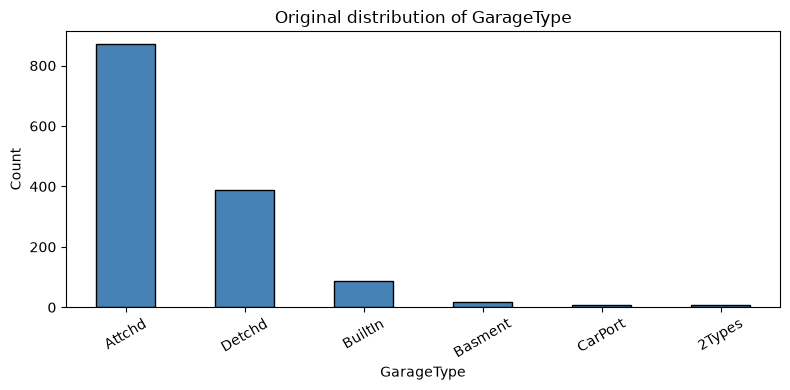

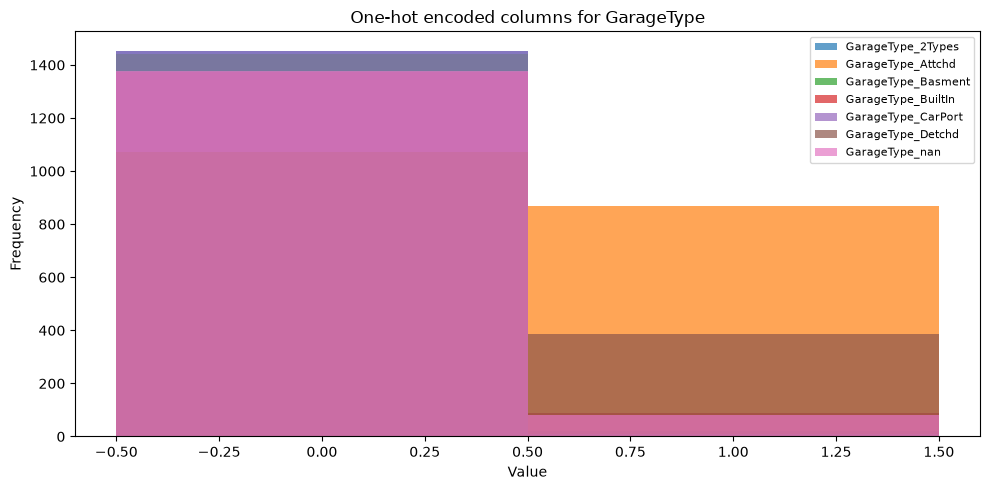

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

# Load data
train = pd.read_csv(r"house-prices-advanced-regression-techniques\train.csv")

# Choose a categorical feature
feature = "GarageType"

# 1) Original categorical feature distribution
plt.figure(figsize=(8, 4))
train[feature].value_counts().plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)
plt.title(f"Original distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 2) One-hot encoding of the selected feature
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(train[[feature]])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out([feature])
)

# 3) Plot one-hot encoded columns
plt.figure(figsize=(10, 5))
for col in encoded_df.columns:
    plt.hist(encoded_df[col], bins=[-0.5, 0.5, 1.5], alpha=0.7, label=col)

plt.title(f"One-hot encoded columns for {feature}")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

##### Q5) Using ordinary least squares (OLS), try to predict house prices on this dataset. Choose the features (or combinations of features) you would like to use or ignore, provided you justify your choice. Evaluate your predictions on the training set using the MSE and the R2 score. For this question, you need to implement OLS from scratch without using any external libraries or packages.

I would use:

1) GrLivArea
2) OverallQual
3) LotArea
4) GarageCars
5) TotalBsmtSF
6) YearBuilt

I would ignore:

1) Id because it is just an identifier
2) categorical variables such as Neighborhood and GarageType for now, because they require one-hot encoding and would make the OLS implementation more complicated


This is a reasonable choice because these numeric features are directly related to house size, quality, and value.

In [12]:
import numpy as np
import pandas as pd

# Load dataset
df = pd.read_csv(r"house-prices-advanced-regression-techniques\train.csv")

# Select a small but strong set of numeric predictors
features = ["GrLivArea", "OverallQual", "LotArea", "GarageCars", "TotalBsmtSF", "YearBuilt"]
target = "SalePrice"

# Keep only relevant columns
data = df[features + [target]].copy()

# Drop rows with missing target or predictors
data = data.dropna()

# Fill missing numeric values with median
for col in features:
    data[col] = data[col].fillna(data[col].median())

# Use log-price for better numerical stability
y = np.log1p(data[target].values)

# Design matrix X with intercept
X = data[features].values
X = np.column_stack([np.ones(len(X)), X])

# OLS estimate: beta = (X^T X)^(-1) X^T y
beta = np.linalg.solve(X.T @ X, X.T @ y)

# Predictions
y_pred = X @ beta

# Computing MSE
mse = np.mean((y_pred - y) ** 2)

# Computing R^2
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print("OLS coefficients:", beta)
print("MSE:", mse)
print("R^2:", r2)



OLS coefficients: [5.92099530e+00 2.25620528e-04 1.06850629e-01 3.31637274e-06
 8.40137167e-02 1.05581108e-04 2.44230734e-03]
MSE: 0.029026887890923336
R^2: 0.8179566710738895


##### Q6) Train your model using all of the training data (all data points, but not necessarily all the features) and test it using the testing data.

I chose the parameters :
1) GrLivArea
2) OverallQual
3) LotArea
4) GarageCars
5) TotalBsmtSF
6) YearBuilt


In [18]:


import numpy as np
import pandas as pd

# Load data
train = pd.read_csv(r"house-prices-advanced-regression-techniques\train.csv")
test = pd.read_csv(r"house-prices-advanced-regression-techniques\test.csv")

# Selected features
features = ["GrLivArea", "OverallQual", "LotArea", "GarageCars", "TotalBsmtSF", "YearBuilt"]

# Prepare training data
X_train = train[features].copy()
y_train = np.log1p(train["SalePrice"])

# Prepare test data
X_test = test[features].copy()

# Fill missing values with median
for col in features:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

# Add intercept column
X_train_m = np.column_stack([np.ones(len(X_train)), X_train.to_numpy()])
X_test_m = np.column_stack([np.ones(len(X_test)), X_test.to_numpy()])

# OLS from scratch:
# beta = (X^T X)^(-1) X^T y
beta = np.linalg.solve(X_train_m.T @ X_train_m, X_train_m.T @ y_train)

# Predict on test set
y_pred_log = X_test_m @ beta
y_pred = np.expm1(y_pred_log)

# Create submission file
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": y_pred
})

submission.to_csv("submission_house_prices.csv", index=False)
print(submission.head())
print("Saved: submission_house_prices.csv")

     Id      SalePrice
0  1461  116126.994790
1  1462  149585.817539
2  1463  164709.419076
3  1464  180341.079630
4  1465  208863.401395
Saved: submission_house_prices.csv
